In [1]:
#Core imports
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
import chromedriver_binary  # auto-manages driver

from bs4 import BeautifulSoup
import time
import pandas as pd

# What these imports do -- So my future me won't get confused
'''
    selenium → opens browser like a human (needed, Myntra is JS-heavy)
    BeautifulSoup → parses HTML cleanly
    chromedriver_binary → avoids driver path headache (blessing)
    time → lets page load (because websites aren’t magic)
'''

'\n    selenium → opens browser like a human (needed, Myntra is JS-heavy)\n    BeautifulSoup → parses HTML cleanly\n    chromedriver_binary → avoids driver path headache (blessing)\n    time → lets page load (because websites aren’t magic)\n'

In [2]:
# Launch a Browser
options = webdriver.ChromeOptions()
options.add_argument("--start-maxmixed")

driver = webdriver.Chrome(options=options)

url = "https://www.myntra.com/"  # test first

driver.get(url)

# What is happening here?
'''
    Chrome opens (yes, actual browser)
    Selenium controls it
    I am now basically a robot pretending to be a human
'''

'\n    Chrome opens (yes, actual browser)\n    Selenium controls it\n    I am now basically a robot pretending to be a human\n'

In [3]:
# Load the product page
product_url = "https://www.myntra.com/jeans/flying+machine/flying-machine-women-flared-high-rise-cotton-light-fade-stretchable-jeans/30717008/buy"
driver.get(product_url)

time.sleep(5)  # let page load

## **Main Thing - To Get HTML of the PAGE**

In [4]:
html = driver.page_source

soup = BeautifulSoup(html, "html.parser")

print(soup.title.text)

Buy Flying Machine Women Flared High Rise Cotton Light Fade Stretchable Jeans  - Jeans for Women 30717008 | Myntra


In [5]:
# FInd Reviews

reviews = soup.find_all("div", class_="user-review-reviewTextWrapper")

for r in reviews[:5]:
    print(r.text.strip())
    print("-" * 50)

Initially great, these jeans fit perfectly (size 34 high-rise flare bootcut) and were super comfortable. The material quality is good, but unfortunately, the color faded away significantly after washes. Stylish, but the longevity of the wash is a concern. Overall I love this jeans .
--------------------------------------------------
Great product, loved the fit, denim and colour...
--------------------------------------------------
Tried all but so far the best one. The feel is so comfortable on skin. The ease of movement in this jeans is amazing. Have no second thought go for it.
--------------------------------------------------


In [6]:
# Find more reviews by scrolling
for _ in range(3):
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

In [7]:
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

## **Extract Structured Data**

In [8]:
data = []

reviews = soup.find_all("div", class_="user-review-reviewTextWrapper")

for r in reviews:
    text = r.text.strip()
    
    data.append({
        "review": text
    })

df = pd.DataFrame(data)
df.head()

,review
0,"Initially great, these jeans fit perfectly (si..."
1,"Great product, loved the fit, denim and colour..."
2,Tried all but so far the best one. The feel is...


## **Sentiment Analysis by TextBlob**

In [9]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["review"].apply(get_sentiment)

df.head()

,review,sentiment
0,"Initially great, these jeans fit perfectly (si...",Positive
1,"Great product, loved the fit, denim and colour...",Positive
2,Tried all but so far the best one. The feel is...,Positive


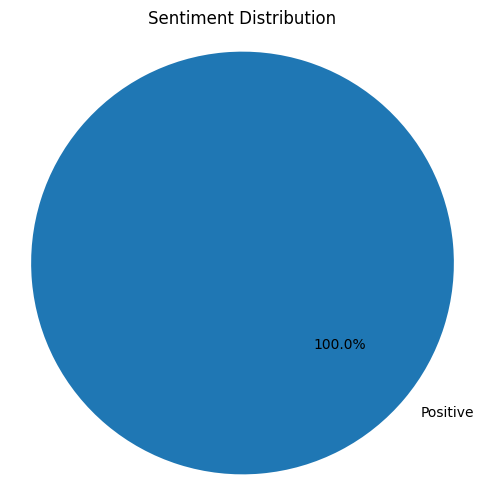

In [15]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution')
plt.axis('equal')
plt.show()

In [ ]:
df.to_csv("reviews.csv", index=False)